
A1. LOAD DATA & EXPLORATORY DATA ANALYSIS
--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

--- Missing Values ---
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

--- Summary Statistics ---
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  206

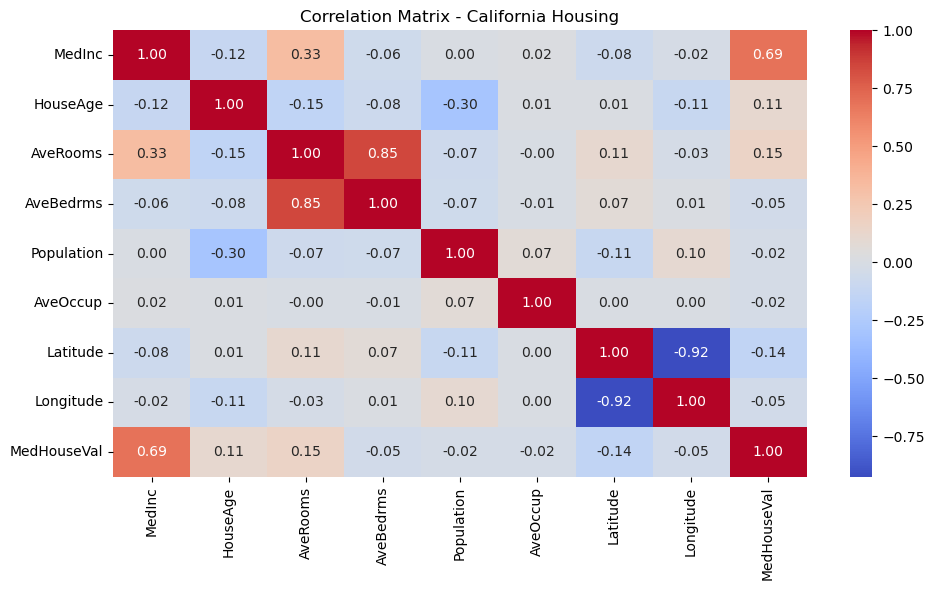


A2. BASELINE LINEAR REGRESSION (Unscaled Features)
MAE:  0.5332
RMSE: 0.7456
R2:   0.5758


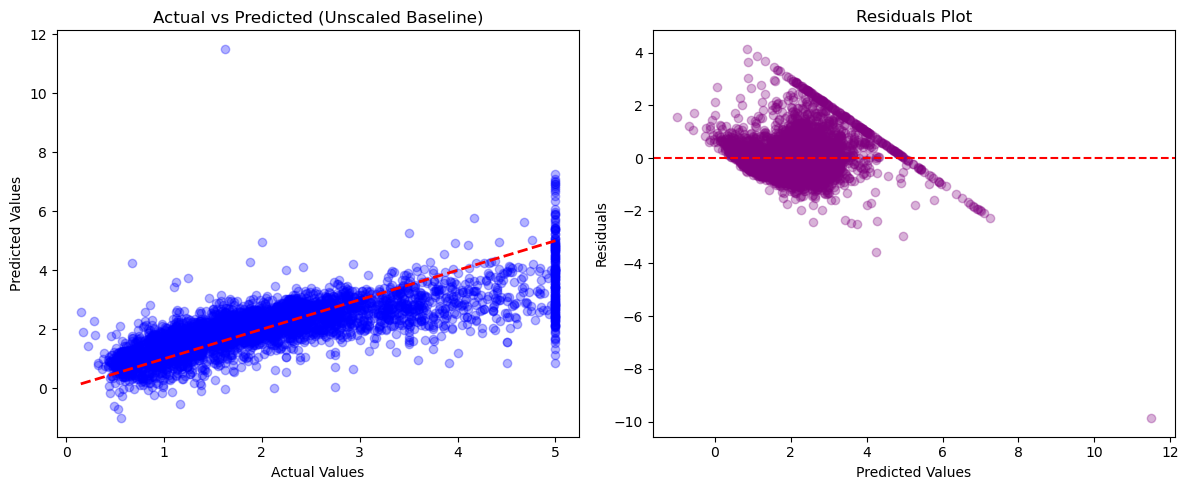


A3. MODEL COMPARISON ON SCALED FEATURES
--- Scaled Model Performance Comparison ---
                             RMSE  R2 Score
Linear Regression        0.745581  0.575788
Ridge Regression         0.745554  0.575819
Decision Tree (depth=5)  0.724234  0.599732


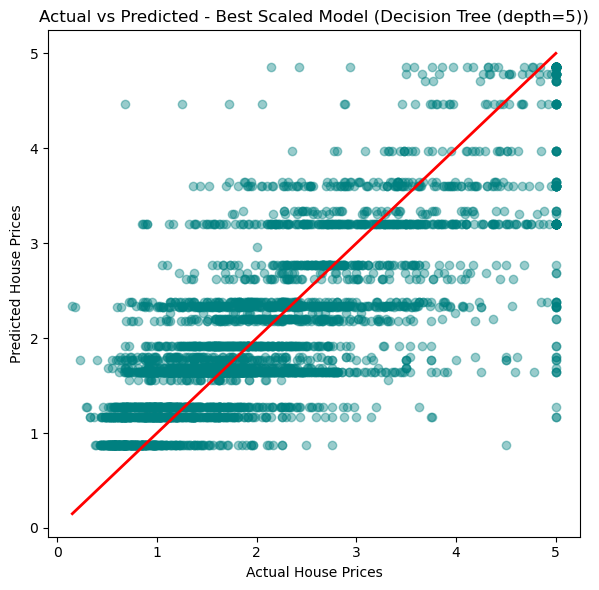


A4. OVERFITTING CHECK, CROSS-VALIDATION & TUNING
--- Overfitting Analysis (Unconstrained Tree) ---
Train RMSE: 0.0000
Test RMSE:  0.7030
A large Train vs Test RMSE gap indicates the unconstrained tree overfits.

5-Fold CV Mean RMSE (unconstrained tree): 0.8957

Best Decision Tree Hyperparameters: {'max_depth': 10, 'min_samples_split': 10}

A5. FINAL REGRESSION MODEL COMPARISON
                 Model      RMSE  R2 Score
0    Linear Regression  0.745581  0.575788
1     Ridge Regression  0.745554  0.575819
2  Tuned Decision Tree  0.645430  0.682099

Best overall regression model: Tuned Decision Tree (RMSE=0.6454)

B1. LOAD DATA, STRATIFIED SPLIT & SCALING

B2. LOGISTIC REGRESSION: BASELINE vs CLASS-WEIGHTED
--- Baseline Logistic Regression ---
Confusion Matrix:
 [[41  1]
 [ 1 71]]

Classification Report:
               precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy         

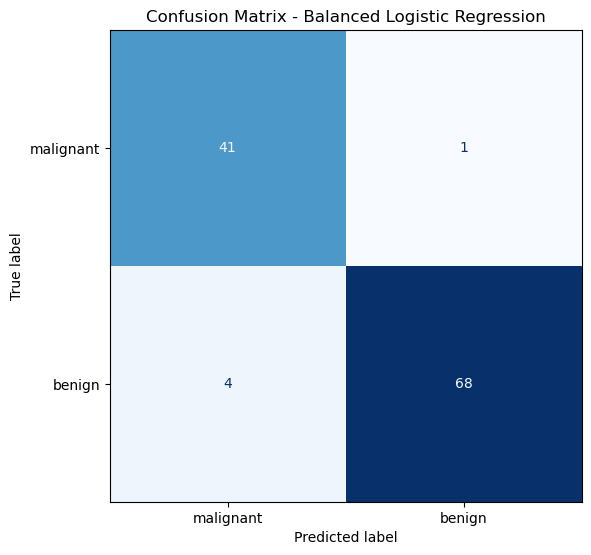


B5. ROC CURVE & AUC (Balanced Logistic Regression)


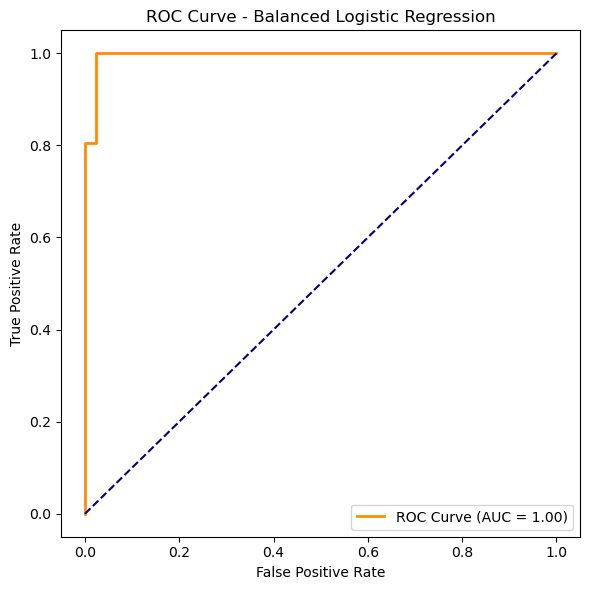


Final Classification AUC: 0.9954

PIPELINE COMPLETE


In [2]:
"""
Combined ML Pipeline: California Housing (Regression) + Breast Cancer (Classification)
=========================================================================================
This script merges 4 separate snippets into one logical, non-redundant pipeline:

  PART A - REGRESSION (California Housing)
    A1. Load data + EDA (info, missing values, stats, correlation heatmap)
    A2. Baseline Linear Regression on UNSCALED features (+ actual vs predicted, residuals)
    A3. Scaled feature comparison: Linear vs Ridge vs Decision Tree
    A4. Overfitting analysis (unconstrained tree) + 5-fold CV + GridSearchCV tuning
    A5. Final regression model comparison summary (best model picked automatically)

  PART B - CLASSIFICATION (Breast Cancer)
    B1. Stratified split + scaling
    B2. Baseline Logistic Regression vs class-weighted (balanced) Logistic Regression
    B3. Decision Tree Classifier as an alternative model
    B4. Confusion matrices, classification reports
    B5. ROC curve + AUC for the best classifier
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, roc_auc_score
)

RANDOM_STATE = 42


def section(title):
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


# =========================================================================
# PART A - REGRESSION: CALIFORNIA HOUSING
# =========================================================================

# ---- A1. Load Data + EDA -------------------------------------------------
section("A1. LOAD DATA & EXPLORATORY DATA ANALYSIS")

housing = fetch_california_housing(as_frame=True)
df = pd.concat([housing.data, housing.target.rename("MedHouseVal")], axis=1)

print("--- Dataset Info ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Summary Statistics ---")
print(df.describe())

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - California Housing")
plt.tight_layout()
plt.show()

X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]

# ---- A2. Baseline Linear Regression on UNSCALED data ----------------------
section("A2. BASELINE LINEAR REGRESSION (Unscaled Features)")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

baseline_lr = LinearRegression()
baseline_lr.fit(X_train, y_train)
y_pred_baseline = baseline_lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = rmse(y_test, y_pred_baseline)
baseline_r2 = r2_score(y_test, y_pred_baseline)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {baseline_rmse:.4f}")
print(f"R2:   {baseline_r2:.4f}")

# Actual vs Predicted + Residuals
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_baseline, alpha=0.3, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Unscaled Baseline)")

residuals = y_test - y_pred_baseline
plt.subplot(1, 2, 2)
plt.scatter(y_pred_baseline, residuals, alpha=0.3, color="purple")
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals Plot")

plt.tight_layout()
plt.show()

# ---- A3. Scaled Feature Comparison: Linear vs Ridge vs Tree ---------------
section("A3. MODEL COMPARISON ON SCALED FEATURES")

reg_scaler = StandardScaler()
X_scaled = reg_scaler.fit_transform(X)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE
)

candidate_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree (depth=5)": DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE)
}

scaled_results = {}
fitted_models = {}
for name, model in candidate_models.items():
    model.fit(X_train_s, y_train_s)
    preds = model.predict(X_test_s)
    scaled_results[name] = {"RMSE": rmse(y_test_s, preds), "R2 Score": r2_score(y_test_s, preds)}
    fitted_models[name] = model

scaled_results_df = pd.DataFrame(scaled_results).T
print("--- Scaled Model Performance Comparison ---")
print(scaled_results_df)

# Visualize the best-performing model from this round (lowest RMSE), not hardcoded
best_scaled_name = scaled_results_df["RMSE"].idxmin()
best_scaled_model = fitted_models[best_scaled_name]
y_pred_best_scaled = best_scaled_model.predict(X_test_s)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_s, y_pred_best_scaled, alpha=0.4, color="teal")
plt.plot([y_test_s.min(), y_test_s.max()], [y_test_s.min(), y_test_s.max()], color="red", lw=2)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title(f"Actual vs Predicted - Best Scaled Model ({best_scaled_name})")
plt.tight_layout()
plt.show()

# ---- A4. Overfitting Analysis, Cross-Validation, Hyperparameter Tuning ----
section("A4. OVERFITTING CHECK, CROSS-VALIDATION & TUNING")

tree_overfit = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree_overfit.fit(X_train_s, y_train_s)

train_rmse = rmse(y_train_s, tree_overfit.predict(X_train_s))
test_rmse = rmse(y_test_s, tree_overfit.predict(X_test_s))

print("--- Overfitting Analysis (Unconstrained Tree) ---")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE:  {test_rmse:.4f}")
print("A large Train vs Test RMSE gap indicates the unconstrained tree overfits.")

cv_scores = cross_val_score(
    tree_overfit, X_scaled, y,
    scoring="neg_root_mean_squared_error", cv=5
)
print(f"\n5-Fold CV Mean RMSE (unconstrained tree): {-cv_scores.mean():.4f}")

param_grid = {"max_depth": [3, 5, 7, 10], "min_samples_split": [2, 5, 10]}
grid = GridSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5
)
grid.fit(X_train_s, y_train_s)
print(f"\nBest Decision Tree Hyperparameters: {grid.best_params_}")

best_tree = grid.best_estimator_
tuned_preds = best_tree.predict(X_test_s)
tuned_rmse = rmse(y_test_s, tuned_preds)
tuned_r2 = r2_score(y_test_s, tuned_preds)

# ---- A5. Final Regression Summary -----------------------------------------
section("A5. FINAL REGRESSION MODEL COMPARISON")

final_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Tuned Decision Tree"],
    "RMSE": [
        scaled_results["Linear Regression"]["RMSE"],
        scaled_results["Ridge Regression"]["RMSE"],
        tuned_rmse
    ],
    "R2 Score": [
        scaled_results["Linear Regression"]["R2 Score"],
        scaled_results["Ridge Regression"]["R2 Score"],
        tuned_r2
    ]
})
print(final_comparison)

best_row = final_comparison.loc[final_comparison["RMSE"].idxmin()]
print(f"\nBest overall regression model: {best_row['Model']} (RMSE={best_row['RMSE']:.4f})")


# =========================================================================
# PART B - CLASSIFICATION: BREAST CANCER
# =========================================================================

# ---- B1. Load, Stratified Split, Scale -------------------------------------
section("B1. LOAD DATA, STRATIFIED SPLIT & SCALING")

cancer = load_breast_cancer()
X_cls = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_cls = cancer.target

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cls
)

cls_scaler = StandardScaler()
X_train_c_scaled = cls_scaler.fit_transform(X_train_c)
X_test_c_scaled = cls_scaler.transform(X_test_c)

# ---- B2. Baseline vs Balanced Logistic Regression --------------------------
section("B2. LOGISTIC REGRESSION: BASELINE vs CLASS-WEIGHTED")

baseline_log = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline_log.fit(X_train_c_scaled, y_train_c)
y_pred_base = baseline_log.predict(X_test_c_scaled)

print("--- Baseline Logistic Regression ---")
print("Confusion Matrix:\n", confusion_matrix(y_test_c, y_pred_base))
print("\nClassification Report:\n",
      classification_report(y_test_c, y_pred_base, target_names=cancer.target_names))

balanced_log = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
balanced_log.fit(X_train_c_scaled, y_train_c)
y_pred_bal = balanced_log.predict(X_test_c_scaled)

print("--- Class-Weighted (Balanced) Logistic Regression ---")
print("Confusion Matrix:\n", confusion_matrix(y_test_c, y_pred_bal))
print("\nClassification Report:\n",
      classification_report(y_test_c, y_pred_bal, target_names=cancer.target_names))

# ---- B3. Decision Tree Classifier (alternative model) -----------------------
section("B3. DECISION TREE CLASSIFIER (Alternative Model)")

tree_clf = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_clf.fit(X_train_c, y_train_c)  # trees don't require scaling
y_pred_tree = tree_clf.predict(X_test_c)

print("Confusion Matrix:\n", confusion_matrix(y_test_c, y_pred_tree))
print("\nClassification Report:\n",
      classification_report(y_test_c, y_pred_tree, target_names=cancer.target_names))

# ---- B4. Confusion Matrix Visualization for the Balanced Model --------------
section("B4. CONFUSION MATRIX PLOT (Balanced Logistic Regression)")

cm = confusion_matrix(y_test_c, y_pred_bal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cancer.target_names)
fig_cm, ax_cm = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax_cm, cmap="Blues", colorbar=False)
ax_cm.set_title("Confusion Matrix - Balanced Logistic Regression")
plt.tight_layout()
plt.show()

# ---- B5. ROC Curve & AUC ----------------------------------------------------
section("B5. ROC CURVE & AUC (Balanced Logistic Regression)")

y_prob = balanced_log.predict_proba(X_test_c_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test_c, y_prob)
auc = roc_auc_score(y_test_c, y_prob)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Balanced Logistic Regression")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"\nFinal Classification AUC: {auc:.4f}")

section("PIPELINE COMPLETE")

In [3]:
import joblib

# Save regression model & scaler
joblib.dump(best_scaled_model, 'house_price_model.pkl')
joblib.dump(reg_scaler, 'scaler.pkl')

# Save classification model & scaler
joblib.dump(balanced_log, 'cancer_model.pkl')
joblib.dump(cls_scaler, 'cls_scaler.pkl')


['cls_scaler.pkl']